In [8]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

import nest_asyncio
nest_asyncio.apply()

import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
pio.renderers.default = "vscode"            

import matplotlib.pyplot as plt
import matplotlib.pylab as pylab
import matplotlib.dates as mdates
plt.style.use('ggplot')
params = {'legend.fontsize': 'x-large',
        'figure.figsize': (12, 8),
        'axes.labelsize': 'x-large',
        'axes.titlesize':'x-large',
        'xtick.labelsize':'x-large',
        'ytick.labelsize':'x-large'}
pylab.rcParams.update(params)

import pandas as pd
import numpy as np

import datetime
import pytz
NY_tz = pytz.timezone("America/New_York") 
CHI_tz = pytz.timezone("America/Chicago") 
UTC_tz = pytz.timezone("UTC") 

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [9]:
import rateslib as rl
import QuantLib as ql

from Query.IRSwaps.IRSwapQuery import IRSwapQuery, IRSwapStructure
from MDP.IRSwaps.IRSwapsMDP import IRSwapsMDP
from TB.IRSwapsTB import IRSwapsTB, IRSwapValueFunctionMap 
from Query.IRSwaps.IRSwapStructure import IRSwapStructureFunctionMap
from Query.IRSwaps.IRSwapValue import IRSwapValue

from utils.ql_utils import datetime_to_ql_date, ql_date_to_datetime 

In [10]:
# import logging, sys
# for h in logging.root.handlers[:]:
#     logging.root.removeHandler(h)
# logging.basicConfig(
#     level=logging.ERROR,  # or DEBUG
#     stream=sys.stdout,  # send logs to the cell output
#     format="%(asctime)s %(levelname)s [%(name)s] %(message)s",
# )
# logging.getLogger("IRSwapsTB").setLevel(logging.ERROR)
# logging.captureWarnings(True)

import logging
logging.disable(logging.CRITICAL)

In [11]:
# 2025-09-20 18:09:30,966 CRITICAL [ZODB.DB] DB.open() has 19 open connections with a pool_size of 7

In [14]:
# curve_mdp = IRSwapsMDP(source="CME_NY_EOD_LIVE-ql_basic")
# curve_mdp = IRSwapsMDP(source="GSQUANT-rl_basic")
# curve_mdp = IRSwapsMDP(source="SDR_INTRADAY-rl_usd_sofr_mt_misc")
curve_mdp = IRSwapsMDP(source="SDR_INTRADAY-rl_usd_sofr_mtv2_q12x11")
# curve_mdp = IRSwapsMDP(source="SDR_INTRADAY-rl_usd_ois_stir_q12x12", force_refresh_fixings=False)
# irs_tb = IRSwapsTB(mdp=curve_mdp, force_refresh=True)

In [ ]:
ts = NY_tz.localize(datetime.datetime(2025, 9, 24, 17, 00))
# ts = "live"

live_curve = curve_mdp._get_curve(curve_name="USD-SOFR-1D", timestamp=ts, kwargs={"force_refresh": True})


In [22]:
fomc_dated_ois = {
    # "sep25": (rl.dt(2025, 9, 17), rl.dt(2025, 10, 29)),
    "oct25": (rl.dt(2025, 10, 29), rl.dt(2025, 12, 10)),
    "dec25": (rl.dt(2025, 12, 10), rl.dt(2026, 1, 28)),
    "jan26": (rl.dt(2026, 1, 28), rl.dt(2026, 3, 18)),
    "mar26": (rl.dt(2026, 3, 18), rl.dt(2026, 4, 29)),
    "apr26": (rl.dt(2026, 4, 29), rl.dt(2026, 6, 17)),
    "jun26": (rl.dt(2026, 6, 17), rl.dt(2026, 7, 29)),
    "jul26": (rl.dt(2026, 7, 29), rl.dt(2026, 9, 16)),
    "sep26": (rl.dt(2026, 9, 16), rl.dt(2026, 10, 28)),
    "oct26": (rl.dt(2026, 10, 28), rl.dt(2026, 12, 9)),
    "dec26": (rl.dt(2026, 12, 9), rl.dt(2027, 1, 27)),
}


def build_fomc_ois(meeting: str, rl_curve: rl.Curve, risk=None, notional=None, rl_irs_swap_kargs={}):
    assert risk is not None or notional is not None, "Must pass in `risk` or `notional`"

    if risk is not None:
        unit_delta = rl.IRS(
            effective=fomc_dated_ois[meeting][0], termination=fomc_dated_ois[meeting][1], spec="usd_irs_lt_2y", curves=rl_curve, notional=1
        ).analytic_delta(rl_curve)
        notional = risk / unit_delta

    fomc_swap = rl.IRS(
        effective=fomc_dated_ois[meeting][0], termination=fomc_dated_ois[meeting][1], spec="usd_irs_lt_2y", curves=rl_curve, notional=notional, **rl_irs_swap_kargs
    )
    return fomc_swap

In [ ]:
oct25 : 3.870283
dec25 : 3.648781
jan26 : 3.526555
mar26 : 3.406128
apr26 : 3.334102
jun26 : 3.194009

In [56]:
import requests
headers = {'User-Agent': 'Mozilla/5.0 (Macintosh; Intel Mac OS X 10_10_1) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/39.0.2171.95 Safari/537.36'}
url = "https://sdrview.clarusft.com/"
r = requests.get(url, headers=headers, allow_redirects=True)

In [ ]:
ql.LogMixedLinearCubicDiscountCurve

r"""__init__(
LogMixedLinearCubicDiscountCurve self, 
DateVector dates, 
DoubleVector discounts, 
DayCounter dayCounter, 
Calendar calendar=Calendar(), 
LogMixedLinearCubic i=LogMixedLinearCubic()) -> LogMixedLinearCubicDiscountCurve"""


r"""__init__(
LogMixedLinearCubic self, 
Size n=0, 
MixedInterpolation::Behavior behavior=ShareRanges, 
CubicInterpolation::DerivativeApprox da=Spline, 
bool monotonic=True) -> LogMixedLinearCubic"""


200


In [ ]:
ql.PiecewiseLogMixedLinearCubicDiscount(date, helpers, calendar, [], [], ql.LogMixedLinearCubic(n, ql.MixedInterpolation.SplitRanges)) # jumps and jumpDates are empty
ql.PiecewiseLogMixedLinearCubicDiscount
ql.LogMixedLinearCubicDiscountCurve

In [98]:
# import requests
# requests.get("https://www.bondsupermart.com/main/ws/v4/bond-info/bond-factsheet-chart/US912810UA42").json()["yieldChartMap"]["SINCE_INCEPTION"]

In [5]:
from MDP.IRSwaps.SDR_INTRADAY.rl_curve_utils.rl_usd_sofr_mt_builder_parallel import rl_usd_sofr_mt_builder_parallel

In [6]:
start = NY_tz.localize(datetime.datetime(2025, 9, 17, 7, 00))
end = NY_tz.localize(datetime.datetime(2025, 9, 17, 17, 00))
intraday_range = pd.date_range(start=start, end=end, freq="1min")
intraday_range[300:310]

DatetimeIndex(['2025-09-17 12:00:00-04:00', '2025-09-17 12:01:00-04:00',
               '2025-09-17 12:02:00-04:00', '2025-09-17 12:03:00-04:00',
               '2025-09-17 12:04:00-04:00', '2025-09-17 12:05:00-04:00',
               '2025-09-17 12:06:00-04:00', '2025-09-17 12:07:00-04:00',
               '2025-09-17 12:08:00-04:00', '2025-09-17 12:09:00-04:00'],
              dtype='datetime64[ns, America/New_York]', freq='min')

In [8]:
curve = "USD-SOFR-1D"
fixings = pd.read_csv(r"C:\Users\chris\clee\ARBS\MDP\IRSwaps\fixings_cache\USD-SOFR-1D_fixings\2025-09-22\fixings.csv", parse_dates=[curve], index_col=curve)[
    "Fixing"
]
rlcurves_batch = rl_usd_sofr_mt_builder_parallel(
    base_curve_id=f"BULK-SDR_INTRADAY-RL_USD_SOFR_MT_Q12",
    snaps=intraday_range[300:325],
    sofr_fixings=fixings,
    n_ser_contracts=0,
    n_sfr_contracts=12,
    n_plus_fomc_years=3,
    max_workers=10,
)

Prefetching and preparing daily data: 100%|██████████| 1/1 [00:04<00:00,  4.60s/it]
Calibrating BULK-SDR_INTRADAY-RL_USD_SOFR_MT_Q12 curves for 2025-09-17: 100%|██████████| 25/25 [00:00<00:00, 47.75it/s]


In [21]:
fives = rl.IRS(
	effective=rl.dt(2025, 9, 19), termination=rl.dt(2029, 9, 19), spec="usd_irs", notional=100_000_000, 
)

In [17]:
# rlcurves_batch[intraday_range[306]].plot("1d")
# rlcurves_batch[intraday_range[318]].to_json()
# fives.rate(curves=rlcurves_batch[intraday_range[318]])

In [36]:
tss = [
    NY_tz.localize(datetime.datetime(2025, 9, 19, 7, 00)),
    NY_tz.localize(datetime.datetime(2025, 9, 19, 8, 00)),
    NY_tz.localize(datetime.datetime(2025, 9, 19, 9, 00)),
    NY_tz.localize(datetime.datetime(2025, 9, 19, 10, 00)),
    NY_tz.localize(datetime.datetime(2025, 9, 19, 11, 00)),
    NY_tz.localize(datetime.datetime(2025, 9, 19, 12, 00)),
    NY_tz.localize(datetime.datetime(2025, 9, 19, 13, 00)),
    NY_tz.localize(datetime.datetime(2025, 9, 19, 14, 00)),
    NY_tz.localize(datetime.datetime(2025, 9, 19, 15, 00)),
    NY_tz.localize(datetime.datetime(2025, 9, 19, 16, 00)),
    NY_tz.localize(datetime.datetime(2025, 9, 19, 17, 00)),
    "live"
]

bulk_curves = curve_mdp.bulk_get_data(request={"curve_name": "USD-SOFR-1D", "timestamps": tss, "max_workers": 3})
bulk_curves

FETCHING ERIS INTRADAY DISC CURVE...: 100%|██████████| 1/1 [00:00<00:00,  2.66it/s]

SUCCESS: `conv_tol` reached after 12 iterations (levenberg_marquardt), `f_val`: 2.9528339579792895e-08, `time`: 0.1153s


{datetime.datetime(2025, 9, 19, 7, 0, tzinfo=<DstTzInfo 'America/New_York' EDT-1 day, 20:00:00 DST>): RLIRSwapCurve(_rl_curve_id='USD-SOFR-1D', _rl_curve_handle=<rl.Curve:2025-09-19 07:00:00-04:00-SDR_INTRADAY-RL_USD_SOFR_MT_Q12 at 0x1ca5e210b00>, _meta_data={'timestamp': datetime.datetime(2025, 9, 19, 7, 0, tzinfo=<DstTzInfo 'America/New_York' EDT-1 day, 20:00:00 DST>), 'id': '2025-09-19 07:00:00-04:00-SDR_INTRADAY-RL_USD_SOFR_MT_Q12'}),
 datetime.datetime(2025, 9, 19, 8, 0, tzinfo=<DstTzInfo 'America/New_York' EDT-1 day, 20:00:00 DST>): RLIRSwapCurve(_rl_curve_id='USD-SOFR-1D', _rl_curve_handle=<rl.Curve:2025-09-19 08:00:00-04:00-SDR_INTRADAY-RL_USD_SOFR_MT_Q12 at 0x1ca603b50a0>, _meta_data={'timestamp': datetime.datetime(2025, 9, 19, 8, 0, tzinfo=<DstTzInfo 'America/New_York' EDT-1 day, 20:00:00 DST>), 'id': '2025-09-19 08:00:00-04:00-SDR_INTRADAY-RL_USD_SOFR_MT_Q12'}),
 datetime.datetime(2025, 9, 19, 9, 0, tzinfo=<DstTzInfo 'America/New_York' EDT-1 day, 20:00:00 DST>): RLIRSwapCurv

(<Figure size 1200x800 with 1 Axes>,
 <Axes: >,
 [<matplotlib.lines.Line2D at 0x1ca608b3750>])

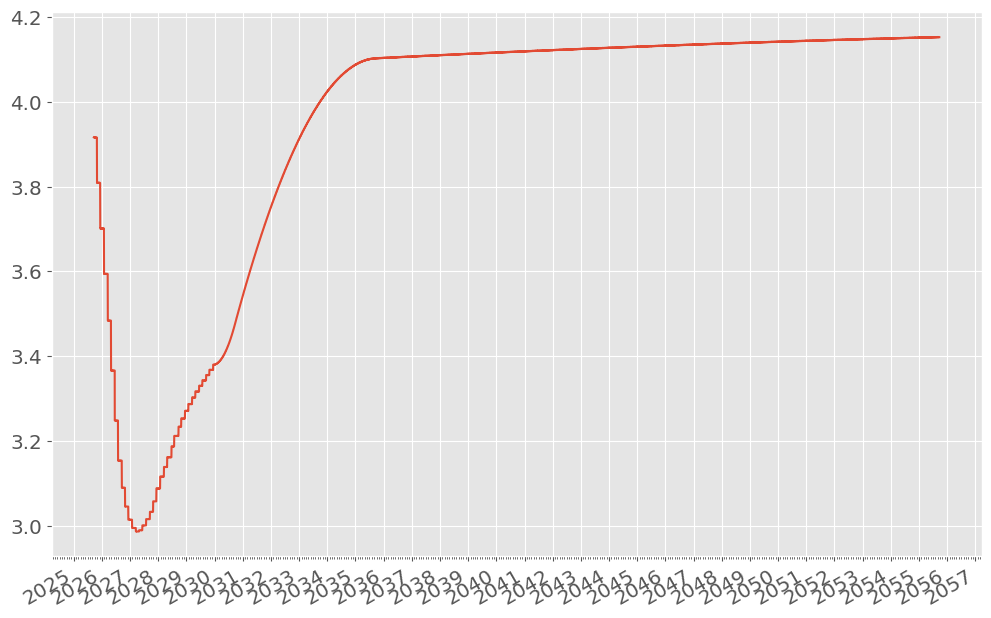

In [39]:
bulk_curves[NY_tz.localize(datetime.datetime(2025, 9, 19, 14, 00))].handle().plot("1d")